# Circuit Diagram, Generated From the Actual Circuit Code

This notebook does **not** hand-draw the circuit. It imports the project's real circuit-building functions (`apply_hea`, `build_observable` from `src/synthetic_bp/stage1a/`, the same ones `stage3/circuit_backend.py` uses to run the RL scheduler) into an actual PennyLane `QNode`, then lets PennyLane's own `qml.draw_mpl` introspect that QNode and render the diagram — so the picture is guaranteed to match whatever the code actually does, gate for gate.

Change `N_QUBITS`, `DEPTH`, `TOPOLOGY`, `ENTANGLER_TYPE` below to regenerate for any configuration (e.g. set `N_QUBITS = 8` for the current report scope).

In [21]:
import sys
from pathlib import Path
sys.path.insert(0, "..")  # project root, so `src...` imports resolve

import numpy as np
import pennylane as qml
from pennylane import numpy as pnp
import matplotlib.pyplot as plt

from src.synthetic_bp.stage1a.ansatz import (
    apply_hea, apply_rotation_block, apply_entanglement_block,
)
from src.synthetic_bp.stage1a.observables import build_observable


## 1. Configuration

Same builders `stage3/circuit_backend.py` imports for the RL-controlled deployment circuit — this is not a separate/simplified copy.

In [22]:
N_QUBITS = 8
DEPTH = 2
TOPOLOGY = "linear"
ENTANGLER_TYPE = "cnot"

def make_circuit(cost_type):
    dev = qml.device("default.qubit", wires=N_QUBITS)
    obs = build_observable(N_QUBITS, cost_type)

    @qml.qnode(dev)
    def circuit(theta, x):
        # encoding: exact copy of stage3/circuit_backend.py _make_qnode()
        for w in range(N_QUBITS):
            qml.RX(x[w], wires=w)
            qml.RY(x[w], wires=w)
        apply_hea(theta, N_QUBITS, DEPTH, TOPOLOGY, ENTANGLER_TYPE)
        return qml.expval(obs)
    return circuit

rng = np.random.default_rng(0)
theta = pnp.array(rng.uniform(-np.pi, np.pi, size=(DEPTH, N_QUBITS, 3)))
x = pnp.array(rng.uniform(0, np.pi, size=N_QUBITS))


## 2. Local cost — sum of single-qubit ⟨Z⟩ over every wire

`build_observable(n, "local")` returns $C(\theta) = \frac{1}{n}\sum_i \langle Z_i \rangle$ — note every wire ends in a measurement, not just one qubit.

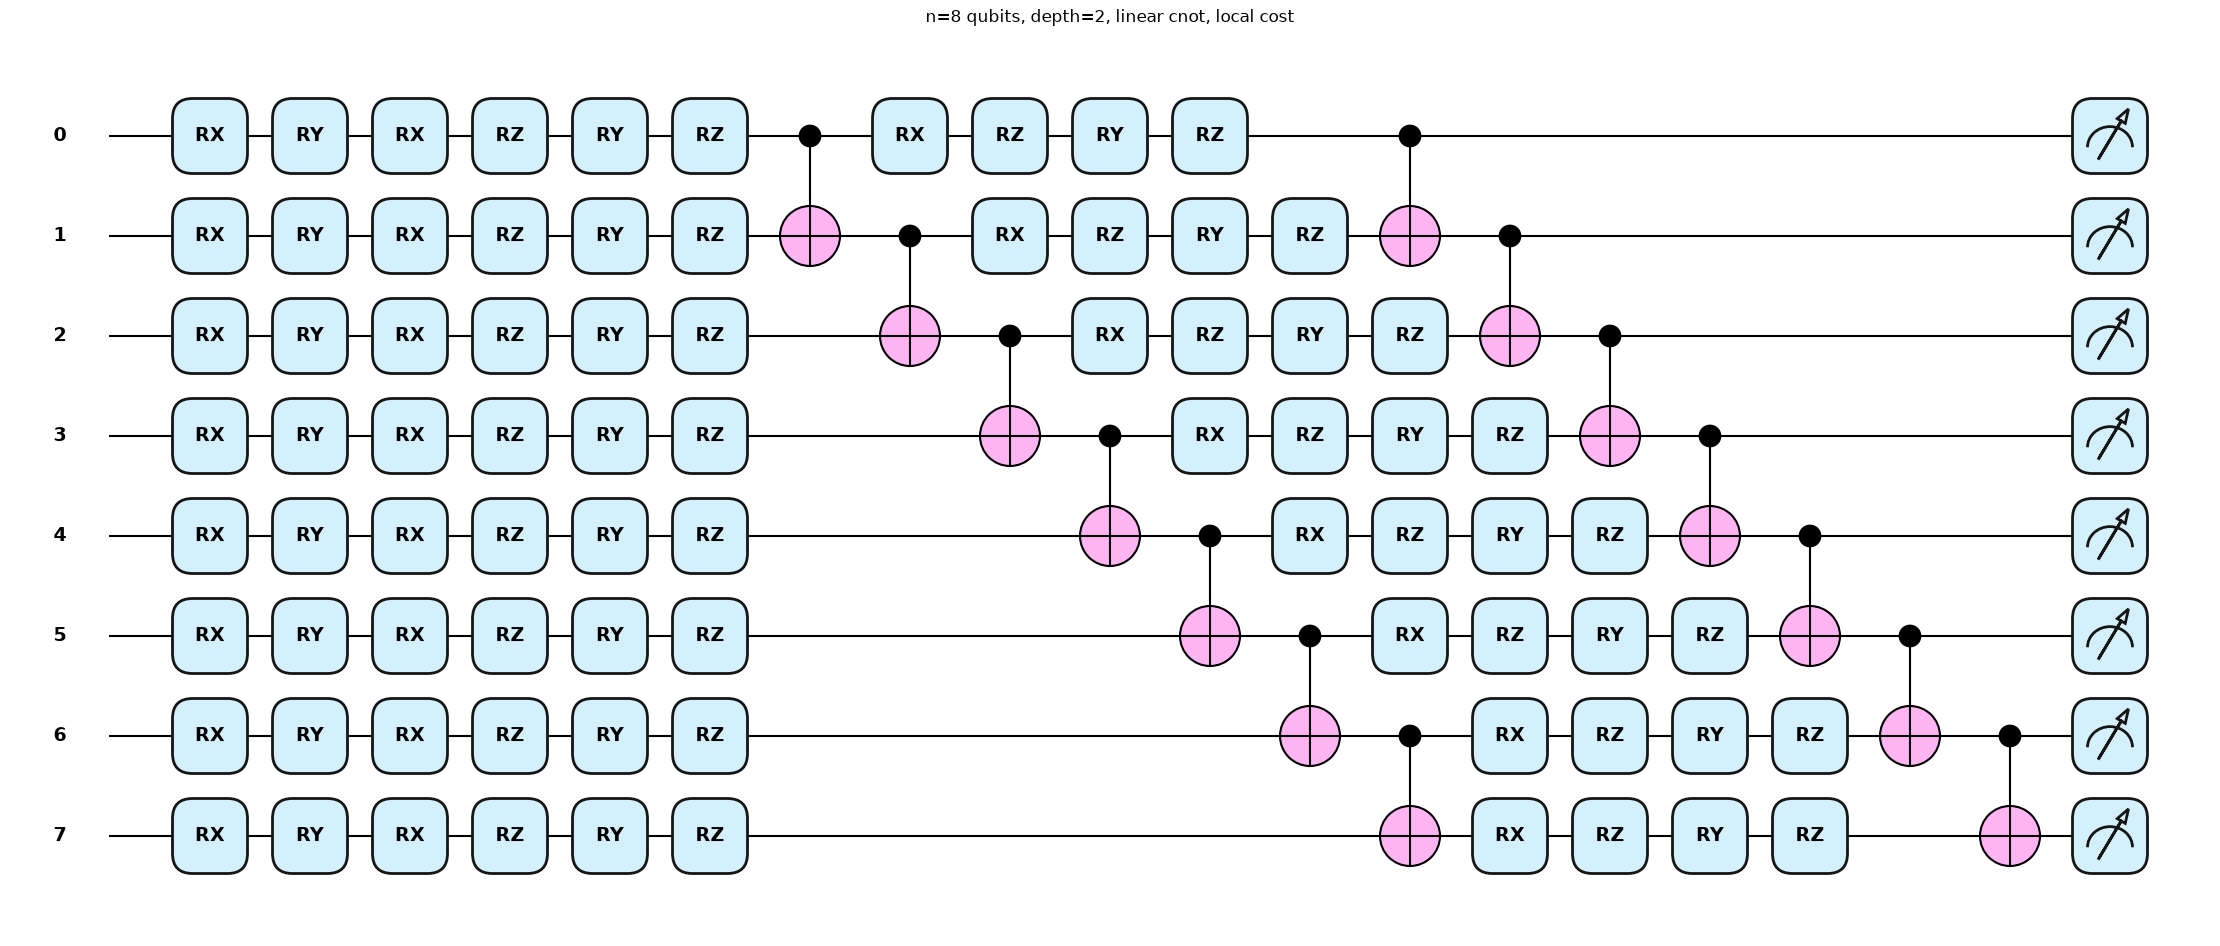

In [23]:
circuit_local = make_circuit("local")
fig, ax = qml.draw_mpl(circuit_local, style="pennylane")(theta, x)
fig.suptitle(f"n={N_QUBITS} qubits, depth={DEPTH}, {TOPOLOGY} {ENTANGLER_TYPE}, local cost", y=1.03)
plt.show()


## 3. Global cost — product of ⟨Z⟩ over every wire

`build_observable(n, "global")` returns $C(\theta) = \langle Z_0 \otimes Z_1 \otimes \cdots \otimes Z_{n-1}\rangle$ — same circuit, only the final observable changes. This is the one that stays in the barren-plateau regime regardless of depth.

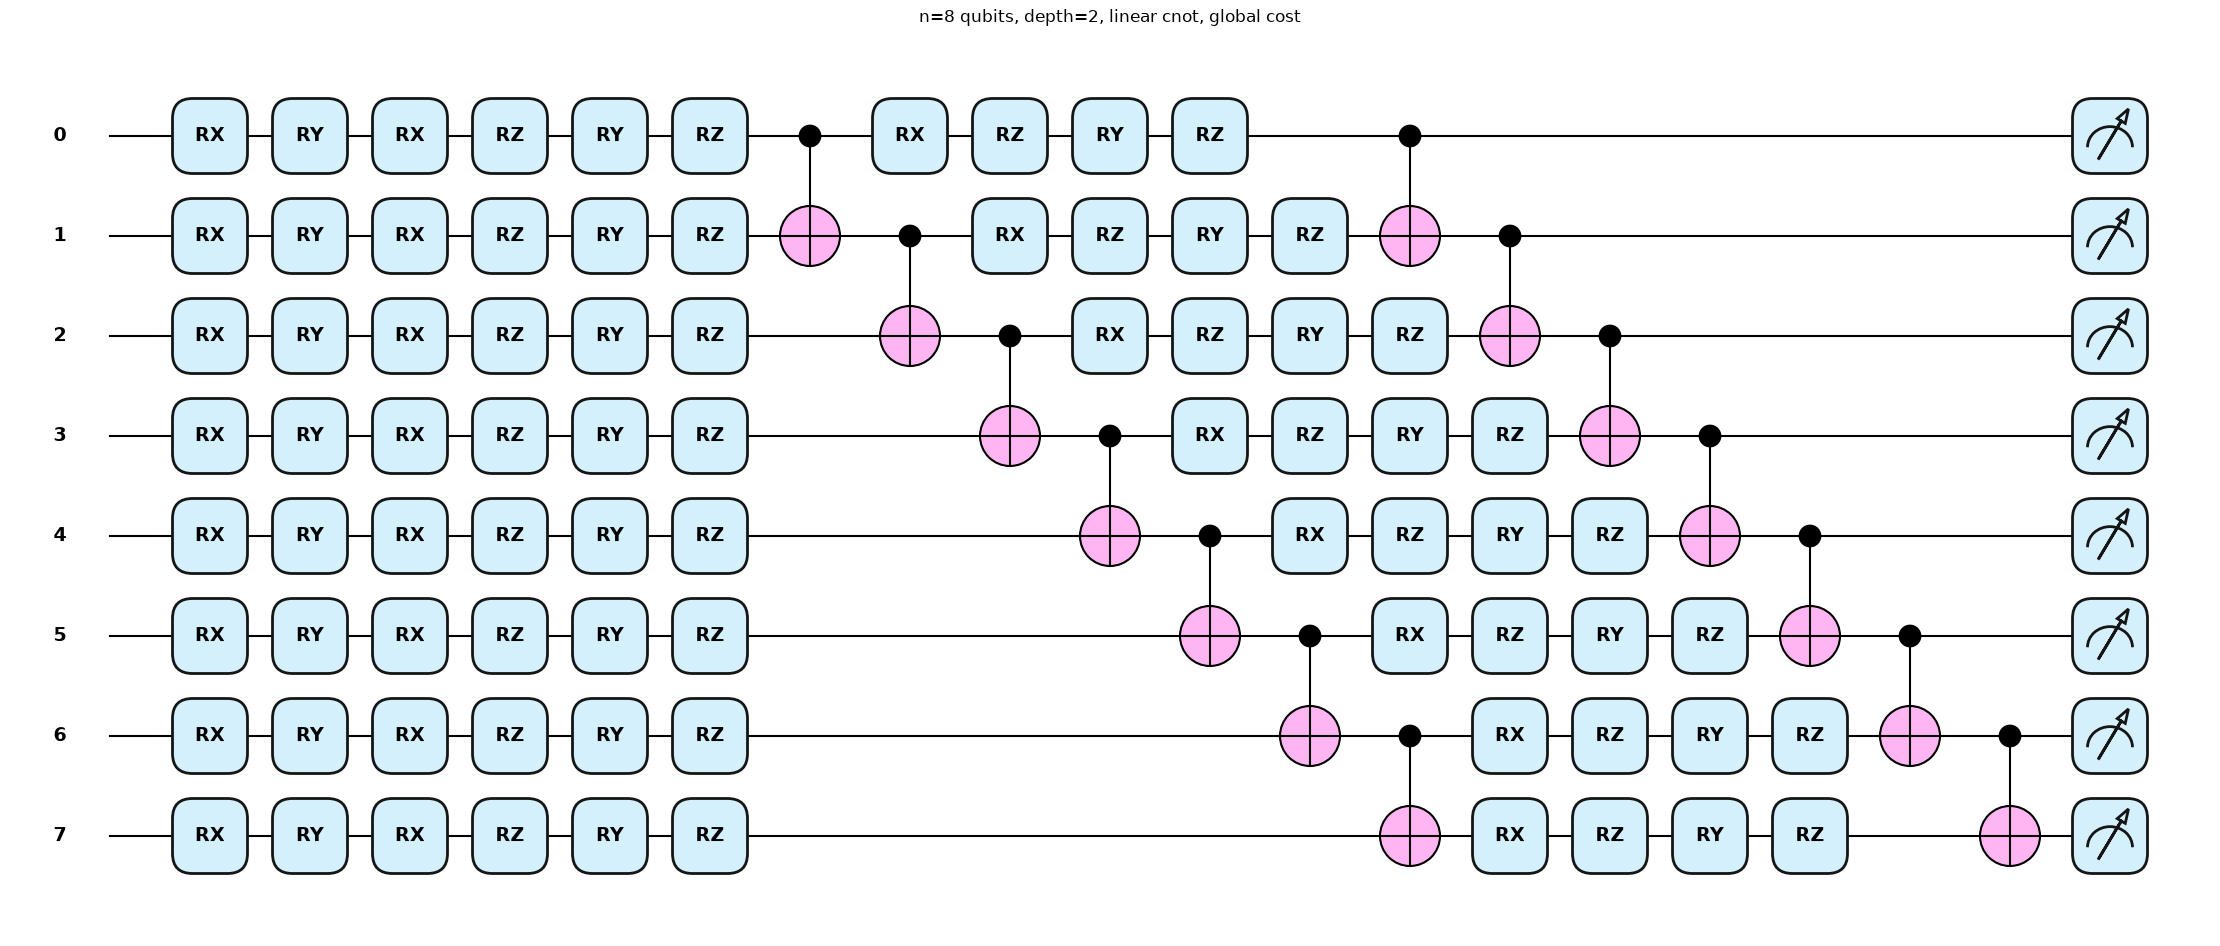

In [24]:
circuit_global = make_circuit("global")
fig, ax = qml.draw_mpl(circuit_global, style="pennylane")(theta, x)
fig.suptitle(f"n={N_QUBITS} qubits, depth={DEPTH}, {TOPOLOGY} {ENTANGLER_TYPE}, global cost", y=1.03)
plt.show()


## 4. Text version (for quick copy/paste into a terminal or LaTeX comment)

In [25]:
print(qml.draw(circuit_local)(theta, x))


0: ──RX(0.26)──RY(0.26)──RX(0.86)───RZ(0.86)───RY(-1.45)──RZ(-2.88)─╭●──RX(0.72)──RZ(0.72) ···
1: ──RX(2.62)──RY(2.62)──RX(-3.04)──RZ(-3.04)──RY(1.97)───RZ(2.59)──╰X─╭●─────────RX(3.02) ···
2: ──RX(2.47)──RY(2.47)──RX(0.67)───RZ(0.67)───RY(1.44)───RZ(0.27)─────╰X────────╭●─────── ···
3: ──RX(0.75)──RY(0.75)──RX(2.73)───RZ(2.73)───RY(1.98)───RZ(-3.12)──────────────╰X─────── ···
4: ──RX(2.75)──RY(2.75)──RX(2.25)───RZ(2.25)───RY(-2.93)──RZ(1.44)──────────────────────── ···
5: ──RX(0.18)──RY(0.18)──RX(-2.04)──RZ(-2.04)──RY(2.28)───RZ(0.26)──────────────────────── ···
6: ──RX(1.06)──RY(1.06)──RX(-1.26)──RZ(-1.26)──RY(-0.49)──RZ(-2.96)─────────────────────── ···
7: ──RX(0.47)──RY(0.47)──RX(-2.36)──RZ(-2.36)──RY(1.07)───RZ(0.92)──────────────────────── ···

0: ··· ──RY(-0.73)──RZ(3.12)────────────╭●────────────────────────────────────────────────────── ···
1: ··· ──RZ(3.02)───RY(1.17)──RZ(0.95)──╰X─────────╭●─────────────────────────────────────────── ···
2: ··· ──RX(1.18)───RZ(1.18)──RY(-0.7

## Notes — what this circuit actually does (verified from the code, not assumed)

- **Encoding**: `RX(x_w)` then `RY(x_w)` on every wire, same angle for both gates (`stage3/circuit_backend.py`), not the single-`RY` angle encoding used in the separate `stage1b/encoding.py` module.
- **Ansatz** (`apply_hea`, one HEA layer): `RX`, `RZ`, `RY`, `RZ` per qubit — four gates, not the clean 3-gate Z-Y-Z Euler decomposition. `RX` and the first `RZ` reuse the **same** parameter (`layer_params[wire, 0]`, see [ansatz.py:81-82](../src/synthetic_bp/stage1a/ansatz.py)) — worth double-checking whether that sharing is intentional.
- **Readout**: `local` = mean of ⟨Z⟩ over *all* qubits (a sum of single-qubit terms), `global` = product of ⟨Z⟩ over *all* qubits — both touch every wire; the difference is sum vs. product, not how many qubits are measured.

## 5. Macro-actions — ADD / PRUNE / FREEZE / KEEP

Illustrated on a smaller n=4 circuit for clarity. All four diagrams are built from the same `apply_rotation_block` / `apply_entanglement_block` primitives `apply_hea` itself calls (`src/synthetic_bp/stage1a/ansatz.py`) — this is not a separate mock-up ansatz.

### Before — baseline, 3 layers

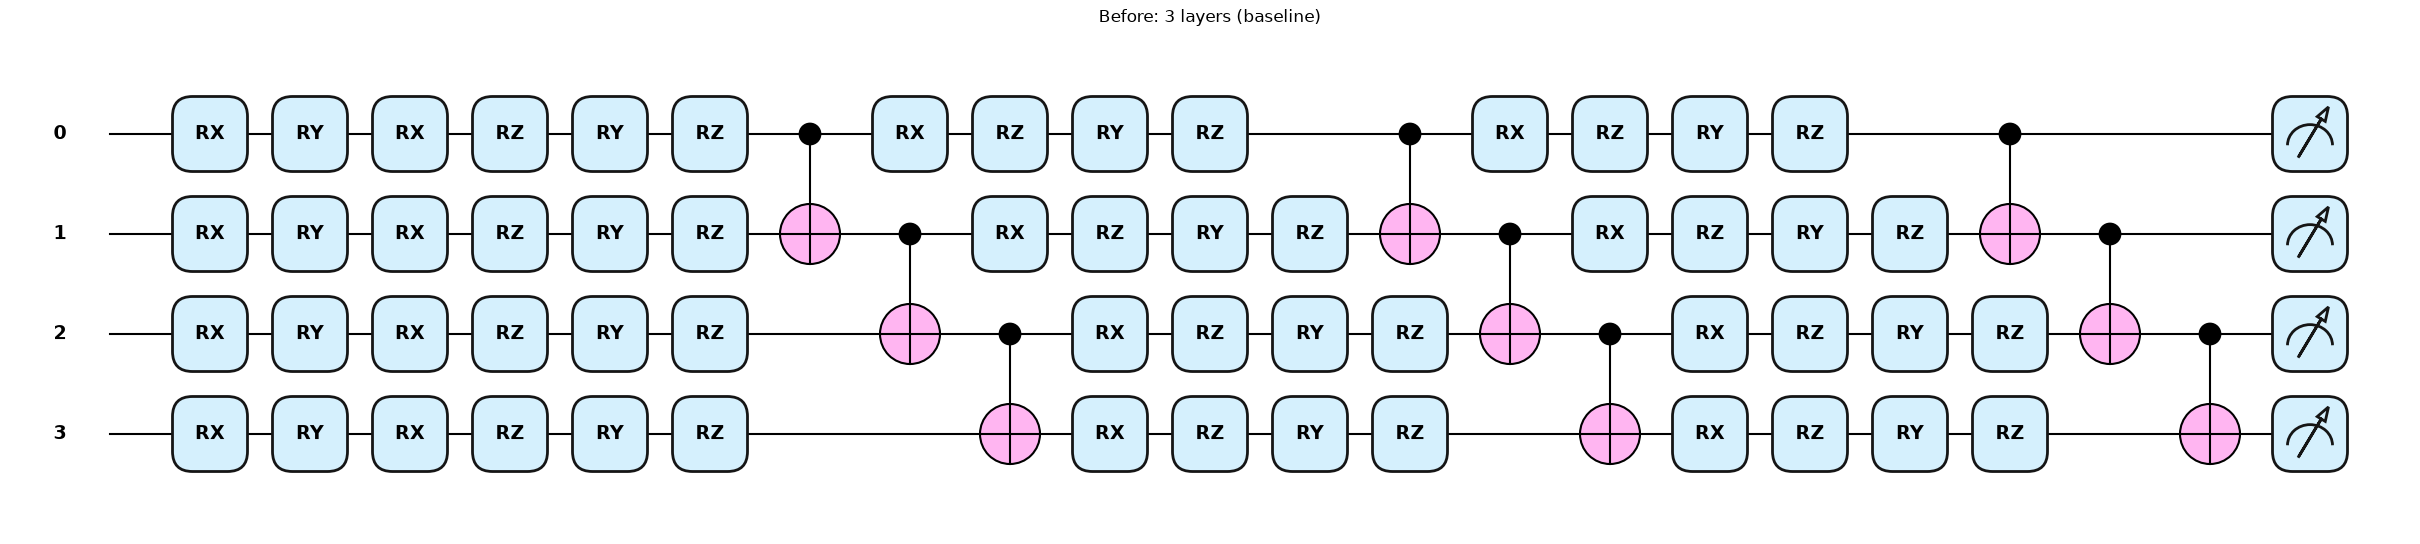

In [26]:
def apply_hea_layers(theta_full, layer_indices, n_qubits, topology, entangler_type):
    """Same building blocks as apply_hea, restricted to the given layer indices."""
    for idx in layer_indices:
        apply_rotation_block(theta_full[idx], n_qubits)
        apply_entanglement_block(n_qubits, topology, entangler_type)

MA_N_QUBITS = 4
MA_TOPOLOGY = "linear"
MA_ENTANGLER = "cnot"

ma_rng = np.random.default_rng(1)
theta_max = pnp.array(ma_rng.uniform(-np.pi, np.pi, size=(4, MA_N_QUBITS, 3)))  # 4 layers ready, in case of ADD
ma_x = pnp.array(ma_rng.uniform(0, np.pi, size=MA_N_QUBITS))
ma_dev = qml.device("default.qubit", wires=MA_N_QUBITS)
ma_obs = build_observable(MA_N_QUBITS, "local")

def draw_layers(layer_indices, title):
    @qml.qnode(ma_dev)
    def circ(theta, x):
        for w in range(MA_N_QUBITS):
            qml.RX(x[w], wires=w)
            qml.RY(x[w], wires=w)
        apply_hea_layers(theta, layer_indices, MA_N_QUBITS, MA_TOPOLOGY, MA_ENTANGLER)
        return qml.expval(ma_obs)
    fig, ax = qml.draw_mpl(circ, style="pennylane")(theta_max, ma_x)
    fig.suptitle(title, y=1.05)
    plt.show()

def text_layers(layer_indices):
    @qml.qnode(ma_dev)
    def circ(theta, x):
        for w in range(MA_N_QUBITS):
            qml.RX(x[w], wires=w)
            qml.RY(x[w], wires=w)
        apply_hea_layers(theta, layer_indices, MA_N_QUBITS, MA_TOPOLOGY, MA_ENTANGLER)
        return qml.expval(ma_obs)
    return qml.draw(circ)(theta_max, ma_x)

draw_layers([0, 1, 2], "Before: 3 layers (baseline)")


**Setup for the animated GIFs below** (schematic layer blocks, not raw PennyLane patches — see the note under each GIF).

In [27]:
import matplotlib.animation as mpl_animation2
from matplotlib.patches import Rectangle as _Rect
from IPython.display import display, Image

LAYER_X = [0.08, 0.30, 0.52, 0.74]
LAYER_W = 0.16

def _layer_strip_gif(out_name, n_frames, frame_fn, title):
    fig, ax = plt.subplots(figsize=(7, 2.6))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
    ax.set_title(title)
    boxes, labels = [], []
    for i in range(4):
        r = _Rect((LAYER_X[i], 0.3), LAYER_W, 0.4, facecolor="#7F77DD",
                   edgecolor="#3C3489", linewidth=1.5)
        ax.add_patch(r)
        boxes.append(r)
        labels.append(ax.text(LAYER_X[i] + LAYER_W / 2, 0.5, f"Layer {i}",
                               ha="center", va="center", fontsize=9))
    extra_text = ax.text(0.5, 0.1, "", ha="center", fontsize=10, color="#993C1D")

    def upd(frame):
        frame_fn(frame, n_frames, boxes, labels, extra_text)
        return boxes + labels + [extra_text]

    anim = mpl_animation2.FuncAnimation(fig, upd, frames=n_frames, blit=False, interval=50)
    fig.tight_layout()
    gif_name = f"{out_name}.gif"
    anim.save(gif_name, writer=mpl_animation2.PillowWriter(fps=20))
    plt.close(fig)
    display(Image(filename=gif_name))  # explicit display -- required so Run All actually shows it

def _add_frame(frame, n_frames, boxes, labels, extra_text):
    t = frame / (n_frames - 1)
    boxes[3].set_visible(True)
    boxes[3].set_alpha(t)
    labels[3].set_alpha(min(t + 0.3, 1))
    extra_text.set_text(f"appending layer 3 — alpha={t:.2f}")

def _prune_frame(frame, n_frames, boxes, labels, extra_text):
    t = frame / (n_frames - 1)
    boxes[3].set_visible(False)
    labels[3].set_visible(False)
    a = 1 - t
    boxes[1].set_alpha(max(a, 0.02))
    labels[1].set_alpha(max(a, 0.05))
    extra_text.set_text(f"pruning layer 1 — alpha={a:.2f}")

def _freeze_frame(frame, n_frames, boxes, labels, extra_text):
    t = frame / (n_frames - 1)
    boxes[3].set_visible(False)
    labels[3].set_visible(False)
    boxes[1].set_linewidth(1.5 + 3.5 * t)
    boxes[1].set_linestyle((0, (4, 2)) if t > 0.5 else "solid")
    labels[1].set_text("Layer 1\n(FROZEN)" if t > 0.5 else "Layer 1")
    extra_text.set_text("gates unchanged — optimizer skips this layer's θ" if t > 0.5 else "")


### ADD_LAYER — appends 1 new layer (layer 3)

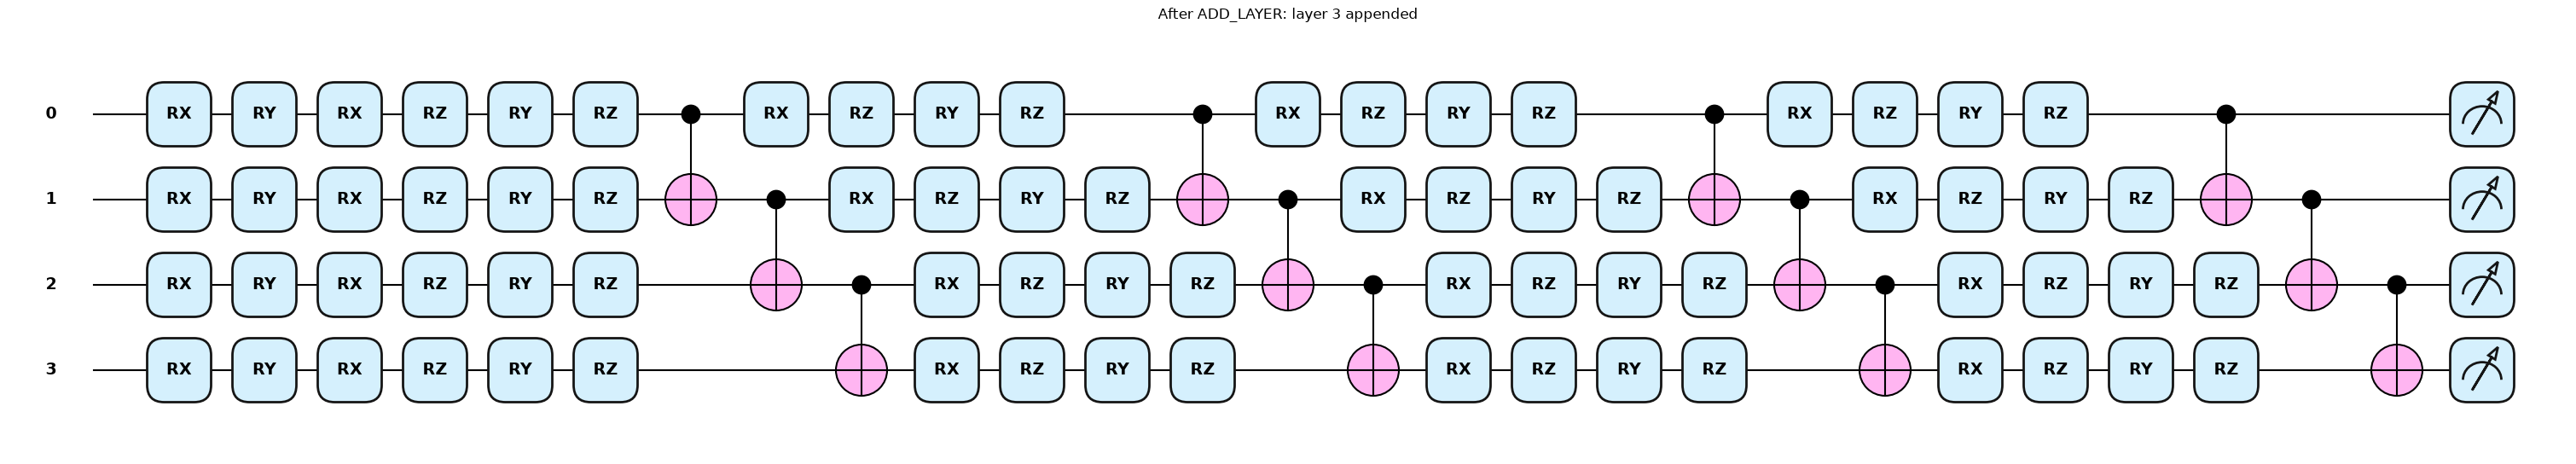

In [28]:
draw_layers([0, 1, 2, 3], "After ADD_LAYER: layer 3 appended")


**Text comparison — before vs. after:**

In [29]:
print("BEFORE (depth = 3)")
print(text_layers([0, 1, 2]))
print("\nAFTER ADD_LAYER (depth = 4)")
print(text_layers([0, 1, 2, 3]))


BEFORE (depth = 3)
0: ──RX(0.46)──RY(0.46)──RX(0.07)───RZ(0.07)───RY(2.83)───RZ(-2.24)─╭●──RX(-1.07)──RZ(-1.07) ···
1: ──RX(2.57)──RY(2.57)──RX(2.82)───RZ(2.82)───RY(-1.18)──RZ(-0.48)─╰X─╭●──────────RX(-0.29) ···
2: ──RX(2.15)──RY(2.15)──RX(2.06)───RZ(2.06)───RY(-0.57)──RZ(0.31)─────╰X─────────╭●──────── ···
3: ──RX(2.47)──RY(2.47)──RX(-2.97)──RZ(-2.97)──RY(1.59)───RZ(0.24)────────────────╰X──────── ···

0: ··· ──RY(1.81)───RZ(-1.24)────────────╭●─────────RX(2.90)──RZ(2.90)───RY(1.41)───RZ(0.26)─ ···
1: ··· ──RZ(-0.29)──RY(-2.30)──RZ(-0.61)─╰X────────╭●─────────RX(-1.40)──RZ(-1.40)──RY(-2.13) ···
2: ··· ──RX(-1.86)──RZ(-1.86)──RY(-1.49)──RZ(1.57)─╰X────────╭●──────────RX(0.10)───RZ(0.10)─ ···
3: ··· ──RX(-1.38)──RZ(-1.38)──RY(-0.09)──RZ(3.02)───────────╰X──────────RX(1.74)───RZ(1.74)─ ···

0: ··· ────────────╭●──────────────┤ ╭<𝓗>
1: ··· ──RZ(2.95)──╰X────────╭●────┤ ├<𝓗>
2: ··· ──RY(-2.41)──RZ(0.78)─╰X─╭●─┤ ├<𝓗>
3: ··· ──RY(0.71)───RZ(2.62)────╰X─┤ ╰<𝓗>

AFTER ADD_LAYER (depth = 4)
0:

**Animated:**

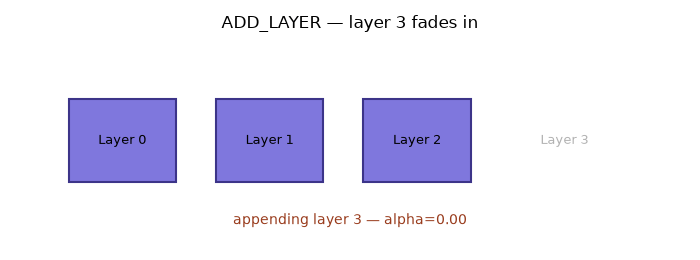

In [30]:
gif_add = _layer_strip_gif("add", 40, _add_frame, "ADD_LAYER — layer 3 fades in")


### PROPOSE_PRUNE, after COMMIT — layer 1 physically removed

This is the end state *after* Approach 3's soft-mask has decayed to 0 and the commit check passed (Section 6 below plots that transition) — the gate block is gone, not just masked.

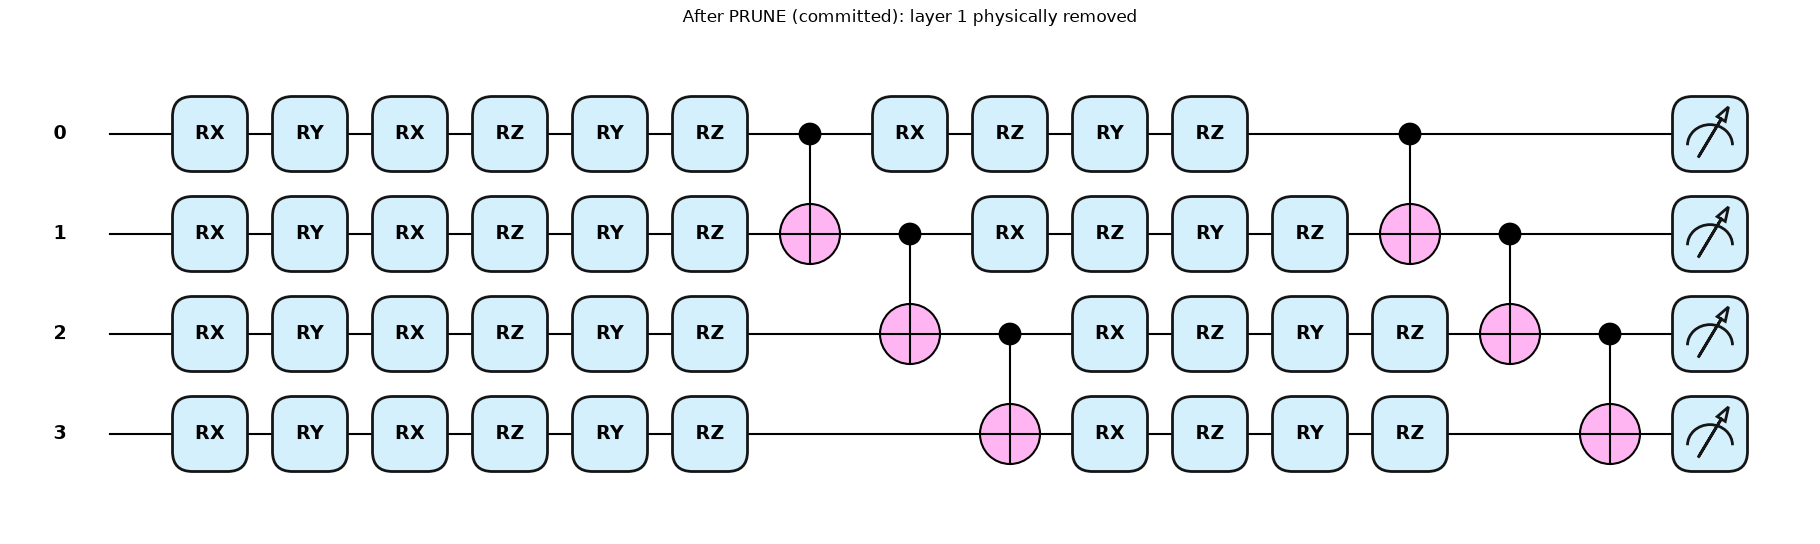

In [31]:
draw_layers([0, 2], "After PRUNE (committed): layer 1 physically removed")


**Text comparison — before vs. after:**

In [32]:
print("BEFORE (depth = 3)")
print(text_layers([0, 1, 2]))
print("\nAFTER PRUNE, committed (depth = 2, layer 1 gone)")
print(text_layers([0, 2]))


BEFORE (depth = 3)
0: ──RX(0.46)──RY(0.46)──RX(0.07)───RZ(0.07)───RY(2.83)───RZ(-2.24)─╭●──RX(-1.07)──RZ(-1.07) ···
1: ──RX(2.57)──RY(2.57)──RX(2.82)───RZ(2.82)───RY(-1.18)──RZ(-0.48)─╰X─╭●──────────RX(-0.29) ···
2: ──RX(2.15)──RY(2.15)──RX(2.06)───RZ(2.06)───RY(-0.57)──RZ(0.31)─────╰X─────────╭●──────── ···
3: ──RX(2.47)──RY(2.47)──RX(-2.97)──RZ(-2.97)──RY(1.59)───RZ(0.24)────────────────╰X──────── ···

0: ··· ──RY(1.81)───RZ(-1.24)────────────╭●─────────RX(2.90)──RZ(2.90)───RY(1.41)───RZ(0.26)─ ···
1: ··· ──RZ(-0.29)──RY(-2.30)──RZ(-0.61)─╰X────────╭●─────────RX(-1.40)──RZ(-1.40)──RY(-2.13) ···
2: ··· ──RX(-1.86)──RZ(-1.86)──RY(-1.49)──RZ(1.57)─╰X────────╭●──────────RX(0.10)───RZ(0.10)─ ···
3: ··· ──RX(-1.38)──RZ(-1.38)──RY(-0.09)──RZ(3.02)───────────╰X──────────RX(1.74)───RZ(1.74)─ ···

0: ··· ────────────╭●──────────────┤ ╭<𝓗>
1: ··· ──RZ(2.95)──╰X────────╭●────┤ ├<𝓗>
2: ··· ──RY(-2.41)──RZ(0.78)─╰X─╭●─┤ ├<𝓗>
3: ··· ──RY(0.71)───RZ(2.62)────╰X─┤ ╰<𝓗>

AFTER PRUNE, committed (depth 

**Animated:**

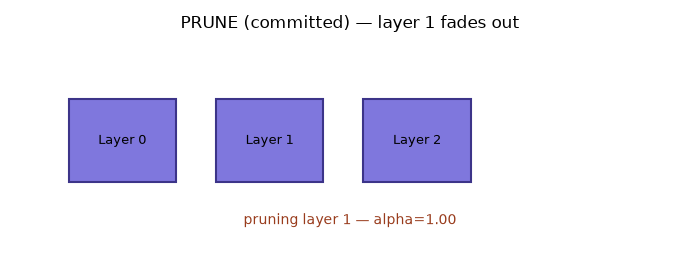

In [33]:
gif_prune = _layer_strip_gif("prune", 40, _prune_frame, "PRUNE (committed) — layer 1 fades out")


### FREEZE — gates are untouched, only the optimizer stops touching θ

FREEZE does not change the circuit picture at all — the 3-layer diagram in "Before" stays exactly as drawn. What changes is invisible to a circuit diagram: layer 1's parameters stop receiving gradient updates. Shown in isolation below just to point at which gates those are.

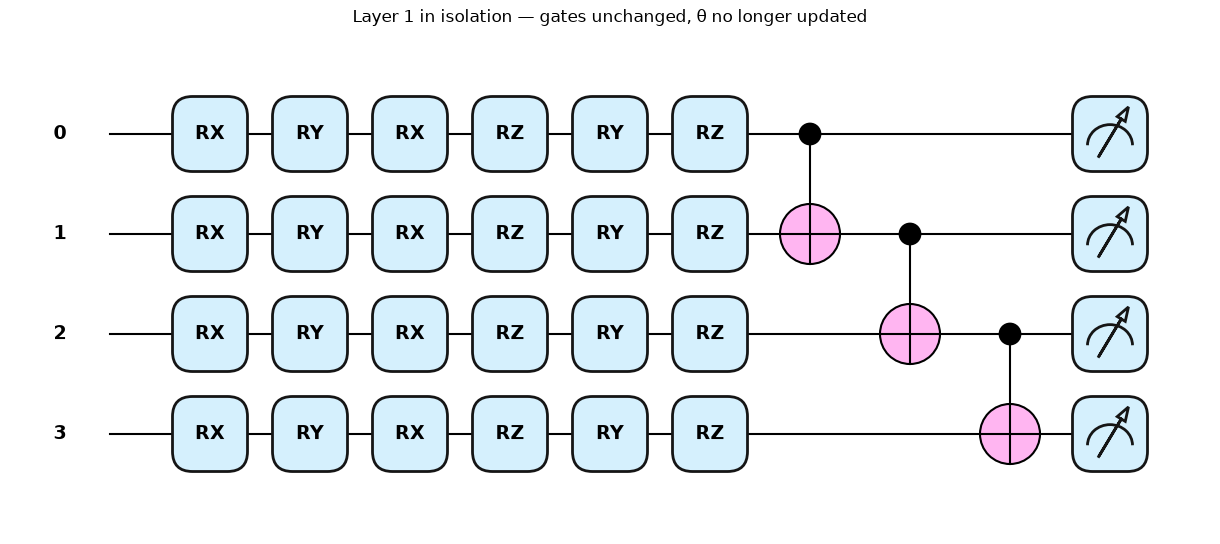

In [34]:
draw_layers([1], "Layer 1 in isolation — gates unchanged, θ no longer updated")


**Text comparison — a circuit diagram cannot show FREEZE (no gate changes), so compare parameter drift over simulated training epochs instead:** layer 1's θ is frozen at its current value forever; layer 0 (left trainable, for contrast) keeps moving under simulated gradient steps.

In [35]:
freeze_rng = np.random.default_rng(2)
theta_frozen = theta_max[1, 0, 0].copy()   # layer 1, wire 0 — this is the one FREEZE locks
theta_active = theta_max[0, 0, 0].copy()   # layer 0, kept trainable for contrast
rows = [(0, float(theta_frozen), float(theta_active))]
for epoch in (1, 2, 3):
    theta_active = theta_active + freeze_rng.normal(0, 0.15)  # simulated gradient step
    rows.append((epoch, float(theta_frozen), float(theta_active)))

print("epoch | layer 1 theta (FROZEN) | layer 0 theta (active)")
print("------|------------------------|------------------------")
for epoch, tf, ta in rows:
    print(f"{epoch:>5} | {tf:>22.4f} | {ta:>22.4f}")


epoch | layer 1 theta (FROZEN) | layer 0 theta (active)
------|------------------------|------------------------
    0 |                -1.0698 |                 0.0743
    1 |                -1.0698 |                 0.1026
    2 |                -1.0698 |                 0.0242
    3 |                -1.0698 |                -0.0377


**Animated:**

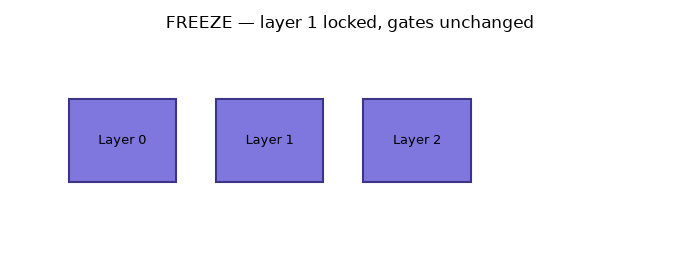

In [36]:
gif_freeze = _layer_strip_gif("freeze", 40, _freeze_frame, "FREEZE — layer 1 locked, gates unchanged")


### KEEP — no diagram needed

KEEP is the identity action: same depth, same masks, same parameters queued for the next gradient step. The "Before" diagram above already *is* the KEEP picture — drawing it again would be the same image.

## 6. Soft-mask function (Approach 3 — cosine annealing)

$$S_{L_j}(t) = \frac{1}{2}\left[1+\cos\left(\frac{\pi t}{T}\right)\right], \qquad \boldsymbol{\theta}_{L_j}(t+1) = \boldsymbol{\theta}_{L_j}(t)\cdot S_{L_j}(t)$$

This is what happens *between* PROPOSE_PRUNE being requested and the COMMIT/ROLLBACK decision in the diagram above: the target layer's rotation angles are scaled down smoothly instead of being deleted outright, so `Adam`'s momentum buffers never see a sudden jump.

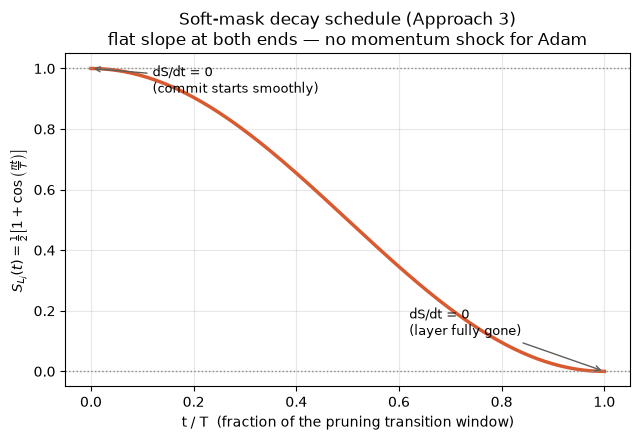

In [37]:
t_frac = np.linspace(0, 1, 200)
S = 0.5 * (1 + np.cos(np.pi * t_frac))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(t_frac, S, color="#D85A30", linewidth=2.5)
ax.axhline(0, color="#888780", linestyle=":", linewidth=1)
ax.axhline(1, color="#888780", linestyle=":", linewidth=1)
ax.set_xlabel("t / T  (fraction of the pruning transition window)")
ax.set_ylabel(r"$S_{L_j}(t) = \frac{1}{2}\left[1+\cos\left(\frac{\pi t}{T}\right)\right]$")
ax.set_title("Soft-mask decay schedule (Approach 3)\nflat slope at both ends — no momentum shock for Adam")
ax.annotate("dS/dt = 0\n(commit starts smoothly)", xy=(0, 1), xytext=(0.12, 0.92),
            fontsize=9, arrowprops=dict(arrowstyle="->", color="#5F5E5A"))
ax.annotate("dS/dt = 0\n(layer fully gone)", xy=(1, 0), xytext=(0.62, 0.12),
            fontsize=9, arrowprops=dict(arrowstyle="->", color="#5F5E5A"))
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


### Animated version

Same curve, but traced over time next to a layer block whose opacity is literally `alpha = S(t)` — the fade you see on the right *is* what "soft mask" means physically.

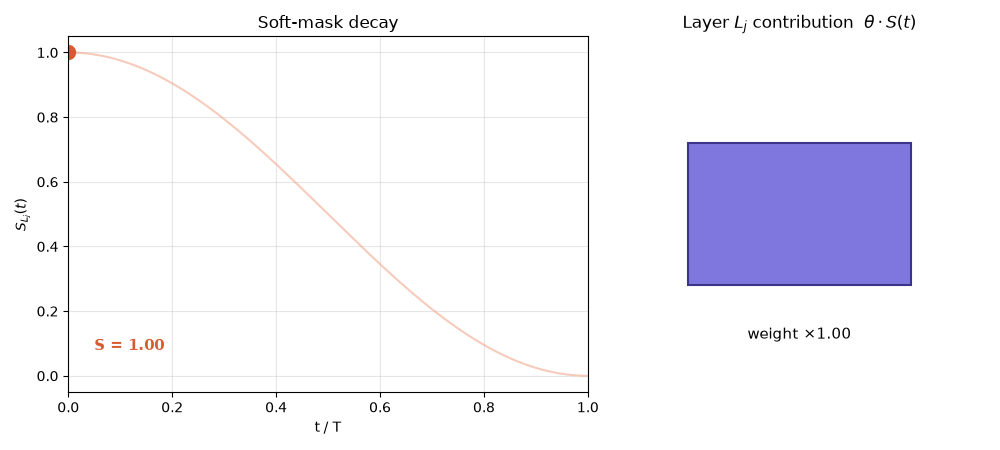

In [38]:
import matplotlib.animation as mpl_animation
from matplotlib.patches import Rectangle
from IPython.display import display, Image

N_FRAMES = 60
fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 4.5), gridspec_kw={"width_ratios": [1.4, 1]})
axL.plot(t_frac, S, color="#F0997B", linewidth=1.5, alpha=0.5)
trace_line, = axL.plot([], [], color="#D85A30", linewidth=3)
dot, = axL.plot([], [], "o", color="#D85A30", markersize=10)
axL.set_xlim(0, 1); axL.set_ylim(-0.05, 1.05)
axL.set_xlabel("t / T"); axL.set_ylabel(r"$S_{L_j}(t)$")
axL.set_title("Soft-mask decay"); axL.grid(True, alpha=0.3)
val_text = axL.text(0.05, 0.08, "", fontsize=11, fontweight="bold", color="#D85A30")

axR.set_xlim(0, 1); axR.set_ylim(0, 1); axR.axis("off")
axR.set_title("Layer $L_j$ contribution  $\\theta \\cdot S(t)$")
rect = Rectangle((0.2, 0.3), 0.6, 0.4, facecolor="#7F77DD", edgecolor="#3C3489", linewidth=1.5)
axR.add_patch(rect)
weight_label = axR.text(0.5, 0.15, "", ha="center", fontsize=11)

def update(frame):
    t = frame / (N_FRAMES - 1)
    s = 0.5 * (1 + np.cos(np.pi * t))
    mask = t_frac <= t
    trace_line.set_data(t_frac[mask], S[mask])
    dot.set_data([t], [s])
    val_text.set_text(f"S = {s:.2f}")
    rect.set_alpha(max(s, 0.03))
    weight_label.set_text(f"weight ×{s:.2f}")
    return trace_line, dot, rect, val_text, weight_label

anim = mpl_animation.FuncAnimation(fig, update, frames=N_FRAMES, blit=False, interval=50)
fig.tight_layout()
anim.save("softmask.gif", writer=mpl_animation.PillowWriter(fps=20))
plt.close(fig)
display(Image(filename="softmask.gif"))  # explicit display -- required so Run All actually shows it


## 7. Commit / Rollback — the safety check after masking

Real logic from `src/synthetic_bp/stage3/mutation_engine.py` and `parameter_registry.py` — this is the mechanism that makes PRUNE (Section 5) and REDUCE safe, and it applies to ADD exactly the same way (the mask just ramps `0 -> 1` instead of `1 -> 0`; a newly added layer that hurts trainability gets rolled back, i.e. removed again).

**One correction versus the earlier design write-up**: the acceptance test is a **relative** threshold, `rel = (peak - start) / start <= max_rel_loss` (2% by default) — not an absolute `L_peak <= L_pre + δ` as an earlier slide/doc phrased it. Worth using the same wording consistently in the report.

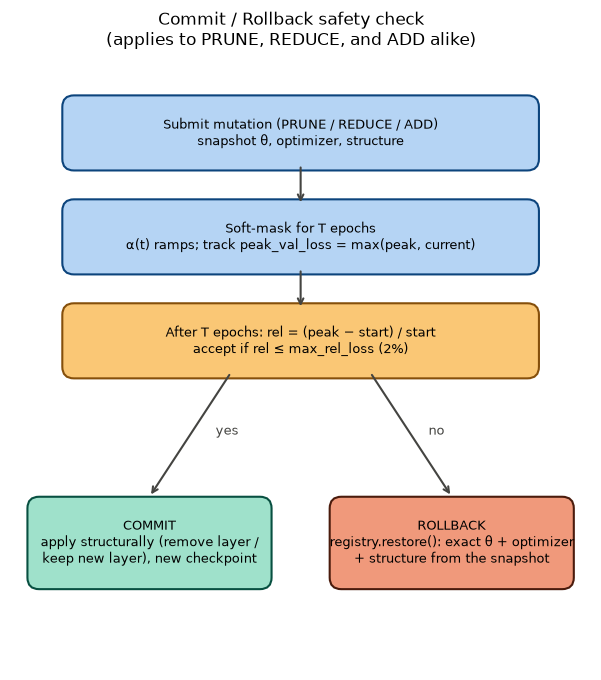

In [39]:
from matplotlib.patches import FancyBboxPatch, Rectangle as _Rect2

def _cr_box(ax, cx, cy, w, h, text, facecolor, edgecolor):
    b = FancyBboxPatch((cx - w / 2, cy - h / 2), w, h,
                        boxstyle="round,pad=0.01,rounding_size=0.02",
                        facecolor=facecolor, edgecolor=edgecolor, linewidth=1.5)
    ax.add_patch(b)
    ax.text(cx, cy, text, ha="center", va="center", fontsize=9)

def _cr_arrow(ax, xy_from, xy_to, label=None):
    ax.annotate("", xy=xy_to, xytext=xy_from,
                arrowprops=dict(arrowstyle="->", color="#444441", linewidth=1.5))
    if label:
        mx, my = (xy_from[0] + xy_to[0]) / 2, (xy_from[1] + xy_to[1]) / 2
        ax.text(mx + 0.03, my, label, fontsize=9, color="#444441")

fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")

_cr_box(ax, 0.5, 0.93, 0.8, 0.11, "Submit mutation (PRUNE / REDUCE / ADD)\nsnapshot θ, optimizer, structure",
        "#B5D4F4", "#0C447C")
_cr_arrow(ax, (0.5, 0.875), (0.5, 0.805))
_cr_box(ax, 0.5, 0.75, 0.8, 0.11, "Soft-mask for T epochs\nα(t) ramps; track peak_val_loss = max(peak, current)",
        "#B5D4F4", "#0C447C")
_cr_arrow(ax, (0.5, 0.695), (0.5, 0.625))
_cr_box(ax, 0.5, 0.57, 0.8, 0.11, "After T epochs: rel = (peak − start) / start\naccept if rel ≤ max_rel_loss (2%)",
        "#FAC775", "#854F0B")
_cr_arrow(ax, (0.38, 0.515), (0.24, 0.30), label="  yes")
_cr_arrow(ax, (0.62, 0.515), (0.76, 0.30), label="no  ")
_cr_box(ax, 0.24, 0.22, 0.4, 0.14, "COMMIT\napply structurally (remove layer /\nkeep new layer), new checkpoint",
        "#9FE1CB", "#085041")
_cr_box(ax, 0.76, 0.22, 0.4, 0.14, "ROLLBACK\nregistry.restore(): exact θ + optimizer\n+ structure from the snapshot",
        "#F0997B", "#4A1B0C")
fig.suptitle("Commit / Rollback safety check\n(applies to PRUNE, REDUCE, and ADD alike)", y=0.99)
plt.show()


**Text: this actually calls the real `MutationEngine` / `ParameterRegistry` / `SimulateBackend`** (`src/synthetic_bp/stage3/`) — the loss numbers fed in are scripted (real training rarely spikes exactly on demand), but the accept/reject decision, the `registry.n_commits` / `n_rollbacks` counters, and the backend's `depth` and layer masks before/after are all read straight off the real objects, not recomputed by hand. Scenario B recovers to a *better* final loss than Scenario A, yet still gets rolled back, because the real engine checks the **peak** loss seen during the window, not the final one.

In [40]:
import sys
sys.path.insert(0, "..")
from src.synthetic_bp.stage3.circuit_backend import SimulateBackend
from src.synthetic_bp.stage3.parameter_registry import ParameterRegistry
from src.synthetic_bp.stage3.mutation_engine import MutationEngine, A_PRUNE, M_COMMIT, M_ROLLBACK

CR_T = 5
CR_MAX_REL = 0.02
cr_start = 0.693

def run_real_mutation(name, loss_trace, target_layer=0):
    backend = SimulateBackend(n_qubits=4, initial_depth=3, seed=0)
    registry = ParameterRegistry(backend)
    engine = MutationEngine(backend, registry, mask_epochs_T=CR_T, max_relative_loss_increase=CR_MAX_REL)

    print(name)
    print(f"before: depth={backend.depth}, masks={[round(l['mask'], 2) for l in backend.layers]}")
    status = engine.submit(A_PRUNE, target_layer, loss_trace[0])
    print(f"engine.submit(A_PRUNE, layer={target_layer}, val_loss={loss_trace[0]:.4f}) -> {status}")
    for t, loss_val in enumerate(loss_trace, 1):
        status = engine.on_epoch(loss_val)
        tail = (f"peak so far={engine.active.peak_val_loss:.4f}" if engine.active is not None
                else "window closed, mutation resolved")
        print(f"  epoch {t}: engine.on_epoch(val_loss={loss_val:.4f}) -> {status}   ({tail})")
    print(f"after:  depth={backend.depth}, masks={[round(l['mask'], 2) for l in backend.layers]}")
    print(f"registry: n_commits={registry.n_commits}, n_rollbacks={registry.n_rollbacks}")
    return status, backend, registry

trace_commit = [0.690, 0.695, 0.688, 0.691, 0.685]
trace_rollback = [0.695, 0.720, 0.740, 0.700, 0.690]
status_c, backend_c, registry_c = run_real_mutation("Scenario A (mild fluctuation)", trace_commit)
print()
status_r, backend_r, registry_r = run_real_mutation("Scenario B (mid-window spike, recovers by the end)", trace_rollback)


Scenario A (mild fluctuation)
before: depth=3, masks=[1.0, 1.0, 1.0]
engine.submit(A_PRUNE, layer=0, val_loss=0.6900) -> in_progress
  epoch 1: engine.on_epoch(val_loss=0.6900) -> in_progress   (peak so far=0.6900)
  epoch 2: engine.on_epoch(val_loss=0.6950) -> in_progress   (peak so far=0.6950)
  epoch 3: engine.on_epoch(val_loss=0.6880) -> in_progress   (peak so far=0.6950)
  epoch 4: engine.on_epoch(val_loss=0.6910) -> in_progress   (peak so far=0.6950)
  epoch 5: engine.on_epoch(val_loss=0.6850) -> committed   (window closed, mutation resolved)
after:  depth=2, masks=[1.0, 1.0]
registry: n_commits=1, n_rollbacks=0

Scenario B (mid-window spike, recovers by the end)
before: depth=3, masks=[1.0, 1.0, 1.0]
engine.submit(A_PRUNE, layer=0, val_loss=0.6950) -> in_progress
  epoch 1: engine.on_epoch(val_loss=0.6950) -> in_progress   (peak so far=0.6950)
  epoch 2: engine.on_epoch(val_loss=0.7200) -> in_progress   (peak so far=0.7200)
  epoch 3: engine.on_epoch(val_loss=0.7400) -> in_progr

**A real simulation, not just two fixed examples** — inject a loss spike of a chosen size at a random-noise-perturbed epoch, call `run_real_mutation()` above (a fresh real `SimulateBackend` + `MutationEngine` each time, not a reimplemented formula), repeat 300 times per spike size, and plot how often the real engine rolls back. Try changing `CR_NOISE_STD`, `CR_SPIKE_EPOCH`, or `CR_N_TRIALS` below and re-running to see how the curve responds.

_mc
before: depth=3, masks=[1.0, 1.0, 1.0]
engine.submit(A_PRUNE, layer=0, val_loss=0.6930) -> in_progress
  epoch 1: engine.on_epoch(val_loss=0.6930) -> in_progress   (peak so far=0.6930)
  epoch 2: engine.on_epoch(val_loss=0.6942) -> in_progress   (peak so far=0.6942)
  epoch 3: engine.on_epoch(val_loss=0.6919) -> in_progress   (peak so far=0.6942)
  epoch 4: engine.on_epoch(val_loss=0.6894) -> in_progress   (peak so far=0.6942)
  epoch 5: engine.on_epoch(val_loss=0.6912) -> committed   (window closed, mutation resolved)
after:  depth=2, masks=[1.0, 1.0]
registry: n_commits=1, n_rollbacks=0
_mc
before: depth=3, masks=[1.0, 1.0, 1.0]
engine.submit(A_PRUNE, layer=0, val_loss=0.6890) -> in_progress
  epoch 1: engine.on_epoch(val_loss=0.6890) -> in_progress   (peak so far=0.6890)
  epoch 2: engine.on_epoch(val_loss=0.6932) -> in_progress   (peak so far=0.6932)
  epoch 3: engine.on_epoch(val_loss=0.6984) -> in_progress   (peak so far=0.6984)
  epoch 4: engine.on_epoch(val_loss=0.6910) -> 

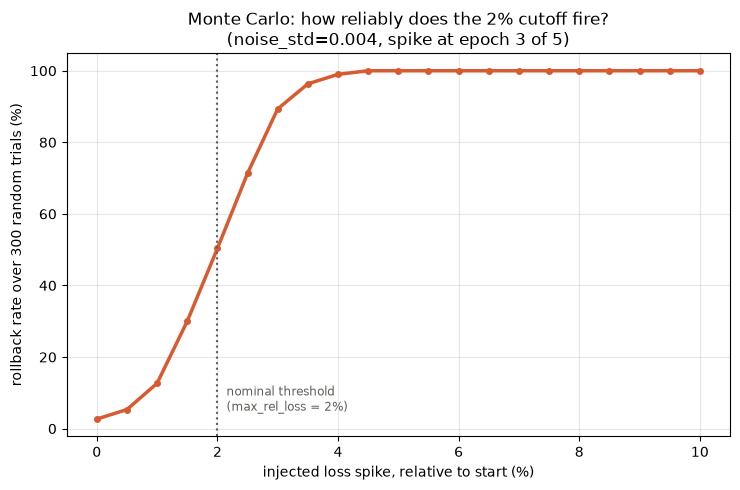

In [41]:
def generate_loss_trace(start, T, noise_std, spike_epoch, spike_size, rng):
    trace = []
    for t in range(1, T + 1):
        val = start + rng.normal(0, noise_std)
        if t == spike_epoch:
            val += spike_size
        trace.append(val)
    return trace

CR_NOISE_STD = 0.004     # try increasing this -- the transition below should blur
CR_SPIKE_EPOCH = 3       # which epoch in the window takes the hit
CR_N_TRIALS = 300        # random trials per spike size
spike_pcts = np.linspace(0, 0.10, 21)   # 0% to 10% relative spike
mc_rng = np.random.default_rng(7)

rollback_frac = []
for pct in spike_pcts:
    spike_size = pct * cr_start
    n_rb = 0
    for _ in range(CR_N_TRIALS):
        trace = generate_loss_trace(cr_start, CR_T, CR_NOISE_STD, CR_SPIKE_EPOCH, spike_size, mc_rng)
        status, _, _ = run_real_mutation("_mc", trace)
        if status == M_ROLLBACK:
            n_rb += 1
    rollback_frac.append(n_rb / CR_N_TRIALS)
rollback_frac = np.array(rollback_frac)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(spike_pcts * 100, rollback_frac * 100, color="#D85A30", linewidth=2.5, marker="o", markersize=4)
ax.axvline(CR_MAX_REL * 100, color="#5F5E5A", linestyle=":", linewidth=1.5)
ax.text(CR_MAX_REL * 100 + 0.15, 5, f"nominal threshold\n(max_rel_loss = {CR_MAX_REL*100:.0f}%)",
        fontsize=8.5, color="#5F5E5A")
ax.set_xlabel("injected loss spike, relative to start (%)")
ax.set_ylabel("rollback rate over 300 random trials (%)")
ax.set_title(f"Monte Carlo: how reliably does the 2% cutoff fire?\n(noise_std={CR_NOISE_STD}, spike at epoch {CR_SPIKE_EPOCH} of {CR_T})")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


**Animated: COMMIT path** — peak stays within 2%, the layer is removed for good.

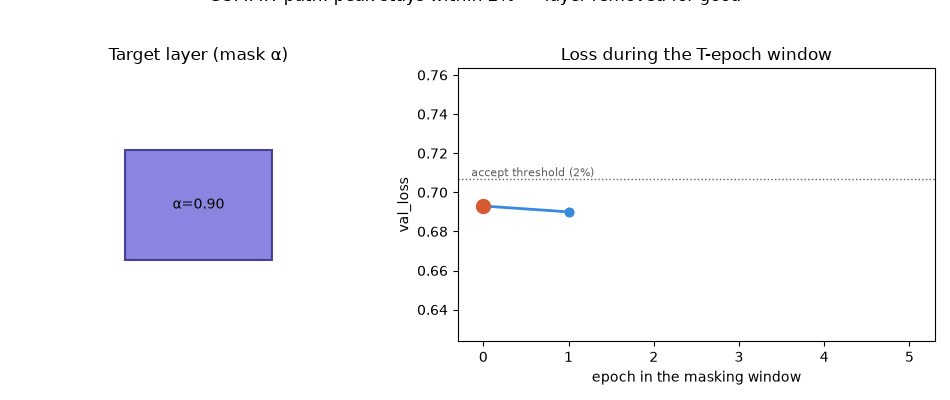

In [42]:
def _commit_rollback_gif(out_name, trace, accept, title):
    n_mask = CR_T
    n_outcome = 8
    n_total = n_mask + n_outcome
    thresh = cr_start * (1 + CR_MAX_REL)

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.5, 4), gridspec_kw={"width_ratios": [1, 1.3]})
    axL.set_xlim(0, 1); axL.set_ylim(0, 1); axL.axis("off")
    axL.set_title("Target layer (mask α)")
    box = _Rect2((0.3, 0.3), 0.4, 0.4, facecolor="#7F77DD", edgecolor="#3C3489", linewidth=1.5)
    axL.add_patch(box)
    box_label = axL.text(0.5, 0.5, "α=1.00", ha="center", va="center", fontsize=10)
    outcome_text = axL.text(0.5, 0.12, "", ha="center", fontsize=11, fontweight="bold")

    axR.set_xlim(-0.3, CR_T + 0.3)
    ymax = max(max(trace), thresh) * 1.08
    axR.set_ylim(cr_start * 0.9, ymax)
    axR.axhline(thresh, color="#5F5E5A", linestyle=":", linewidth=1)
    axR.text(0.02, thresh, f" accept threshold ({CR_MAX_REL*100:.0f}%)", fontsize=8, color="#5F5E5A",
              transform=axR.get_yaxis_transform(), va="bottom")
    axR.set_xlabel("epoch in the masking window"); axR.set_ylabel("val_loss")
    axR.set_title("Loss during the T-epoch window")
    line, = axR.plot([], [], "o-", color="#378ADD", linewidth=2, markersize=6)
    peak_dot, = axR.plot([], [], "o", color="#D85A30", markersize=10, zorder=4)

    xs, ys = [0], [cr_start]

    def upd(frame):
        if frame < n_mask:
            t = frame + 1
            alpha = 0.5 * (1 + np.cos(np.pi * t / CR_T))
            box.set_alpha(max(alpha, 0.03))
            box_label.set_text(f"α={alpha:.2f}")
            xs.append(t); ys.append(trace[t - 1])
            line.set_data(xs, ys)
            peak_idx = int(np.argmax(ys))
            peak_dot.set_data([xs[peak_idx]], [ys[peak_idx]])
        else:
            k = frame - n_mask + 1
            frac = k / n_outcome
            if accept:
                box.set_alpha(0.03)
                outcome_text.set_text("COMMIT")
                outcome_text.set_color("#0F6E56")
            else:
                alpha_back = min(1.0, frac)
                box.set_alpha(alpha_back)
                box_label.set_text(f"α={alpha_back:.2f}")
                outcome_text.set_text("ROLLBACK — restored")
                outcome_text.set_color("#993C1D")
        return box, box_label, outcome_text, line, peak_dot

    fig.suptitle(title, y=1.03)
    fig.tight_layout()
    anim = mpl_animation2.FuncAnimation(fig, upd, frames=n_total, blit=False, interval=180)
    gif_name = f"{out_name}.gif"
    anim.save(gif_name, writer=mpl_animation2.PillowWriter(fps=6))
    plt.close(fig)
    display(Image(filename=gif_name))

_commit_rollback_gif("commit_path", trace_commit, status_c == M_COMMIT,
                     "COMMIT path: peak stays within 2% -> layer removed for good")


**Animated: ROLLBACK path** — peak exceeds 2% mid-window, so the layer snaps back to full strength.

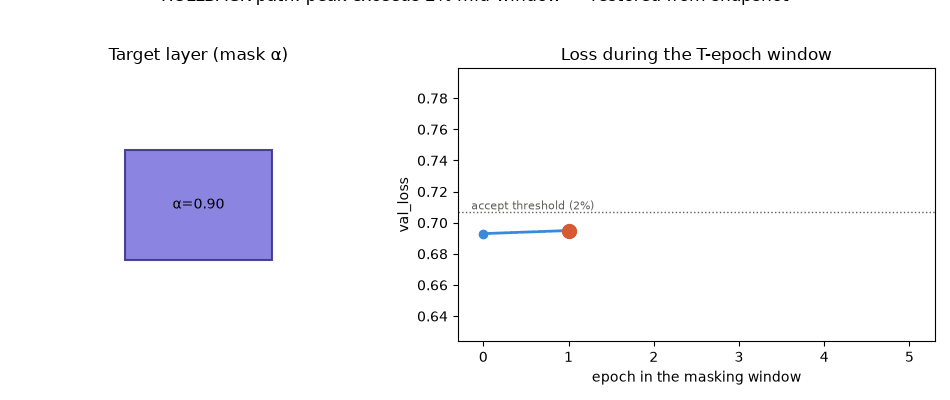

In [43]:
_commit_rollback_gif("rollback_path", trace_rollback, status_r == M_COMMIT,
                     "ROLLBACK path: peak exceeds 2% mid-window -> restored from snapshot")


## Notes — commit / rollback

- The snapshot (`ParameterRegistry.commit_checkpoint`) is taken **before** the mask starts, and covers both `θ` and the classical optimizer's internal state — a rollback is a full revert, not just an undo of the parameter values.
- `ADD_LAYER` goes through the identical safety net (`mutation_engine.py`'s own comment notes this was added specifically because an un-gated `add_layer` that made a barren plateau worse used to be unrecoverable).
- The acceptance check uses the **peak** loss observed anywhere in the `T`-epoch window, not the loss at the end of it — Scenario B above is the concrete illustration of why that distinction matters.